# 4단계 · 성과 분석 & 최적화

이 노트북에서는 전략의 성과를 **깊이 있게 분석**하고, 파라미터를 **최적화**하는 방법을 배웁니다.  
특히 과최적화(Overfitting) 를 방지하는 **in-sample / out-of-sample 검증** 방법에 집중합니다.

## 학습 목표
1. `pf.stats()` 로 샤프비율·최대낙폭(MDD)·승률 분석
2. `pf.plot()` 로 자산 곡선·드로우다운 시각화
3. 파라미터 그리드 서치로 최적 파라미터 탐색
4. 과최적화(Overfitting) 개념 이해 및 방지
5. In-sample / Out-of-sample 분리 검증

---
## ⚠️ 과최적화(Overfitting) 주의

```
과거 데이터로 파라미터를 최적화하면
→ 과거에는 완벽하게 보이지만
→ 미래(실제 시장)에서는 형편없는 결과가 나오는 현상

해결책: 학습 데이터(in-sample)와 검증 데이터(out-of-sample)를 분리!
```

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import matplotlib.pyplot as plt
import seaborn as sns

from vbt_backtest.strategies.golden_cross import run_backtest
from vbt_backtest.optimizer import grid_search
from vbt_backtest.data import load_close

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
close = load_close('AAPL', start='2015-01-01', end='2023-12-31')
print(f'데이터 기간: {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'총 거래일: {len(close)}일')

## 1. pf.stats() — 성과 지표 완전 분석

vectorbt는 다양한 성과 지표를 `pf.stats()` 한 번으로 확인할 수 있습니다.  
각 지표의 **의미**와 **좋은/나쁜 기준**을 이해하는 것이 중요합니다.

In [2]:
# strategies 모듈의 run_backtest 함수로 포트폴리오 생성
pf = run_backtest(close, fast_window=20, slow_window=60)

# 전체 통계 출력
pf.stats()

Start                                2015-01-02 00:00:00
End                                  2023-12-29 00:00:00
Period                                2264 days 00:00:00
Start Value                                        100.0
End Value                                     291.281613
Total Return [%]                              191.281613
Benchmark Return [%]                          686.914311
Max Gross Exposure [%]                             100.0
Total Fees Paid                                 7.315174
Max Drawdown [%]                               24.813661
Max Drawdown Duration                  459 days 00:00:00
Total Trades                                          22
Total Closed Trades                                   21
Total Open Trades                                      1
Open Trade PnL                                  3.692119
Win Rate [%]                                   47.619048
Best Trade [%]                                 48.656829
Worst Trade [%]                

In [3]:
# ─── 핵심 지표별 해석 ─────────────────────────────────────────────
print('=' * 55)
print('핵심 성과 지표 해석 가이드')
print('=' * 55)

total_ret = pf.total_return()
ann_ret   = pf.annualized_return()
sharpe    = pf.sharpe_ratio()
mdd       = pf.max_drawdown()
calmar    = ann_ret / abs(mdd) if mdd != 0 else 0

print(f'\n[수익률]')
print(f'  총 수익률      : {total_ret:.2%}  (기간 전체 누적 수익)')
print(f'  연평균수익률   : {ann_ret:.2%}  (연 단위로 환산, CAGR)')

print(f'\n[위험조정 수익률]')
print(f'  샤프 비율      : {sharpe:.2f}')
print(f'   → 기준: >1.0 양호 / >2.0 우수 / <0 수익률이 무위험수익보다 낮음')

print(f'\n[손실 관련]')
print(f'  최대 낙폭(MDD) : {mdd:.2%}  (고점 대비 최대 손실)')
print(f'   → 기준: >-20% 주의 / >-30% 심각 / >-50% 매우 위험')
print(f'  Calmar 비율    : {calmar:.2f}  (연수익률/MDD, 높을수록 좋음)')

print(f'\n[거래 관련]')
trades = pf.trades
win_rate = trades.win_rate()
print(f'  총 거래수      : {trades.count()}회')
print(f'  승률           : {win_rate:.2%}  (이익 거래 / 전체 거래)')
print(f'   → 참고: 승률 50% 이하라도 손익비가 좋으면 수익 가능')

핵심 성과 지표 해석 가이드

[수익률]
  총 수익률      : 191.28%  (기간 전체 누적 수익)
  연평균수익률   : 18.81%  (연 단위로 환산, CAGR)

[위험조정 수익률]
  샤프 비율      : 0.83
   → 기준: >1.0 양호 / >2.0 우수 / <0 수익률이 무위험수익보다 낮음

[손실 관련]
  최대 낙폭(MDD) : -24.81%  (고점 대비 최대 손실)
   → 기준: >-20% 주의 / >-30% 심각 / >-50% 매우 위험
  Calmar 비율    : 0.76  (연수익률/MDD, 높을수록 좋음)

[거래 관련]
  총 거래수      : 22회
  승률           : 50.00%  (이익 거래 / 전체 거래)
   → 참고: 승률 50% 이하라도 손익비가 좋으면 수익 가능


## 2. pf.plot() — 시각화

vectorbt는 내장 시각화 도구로 다양한 차트를 자동 생성합니다.

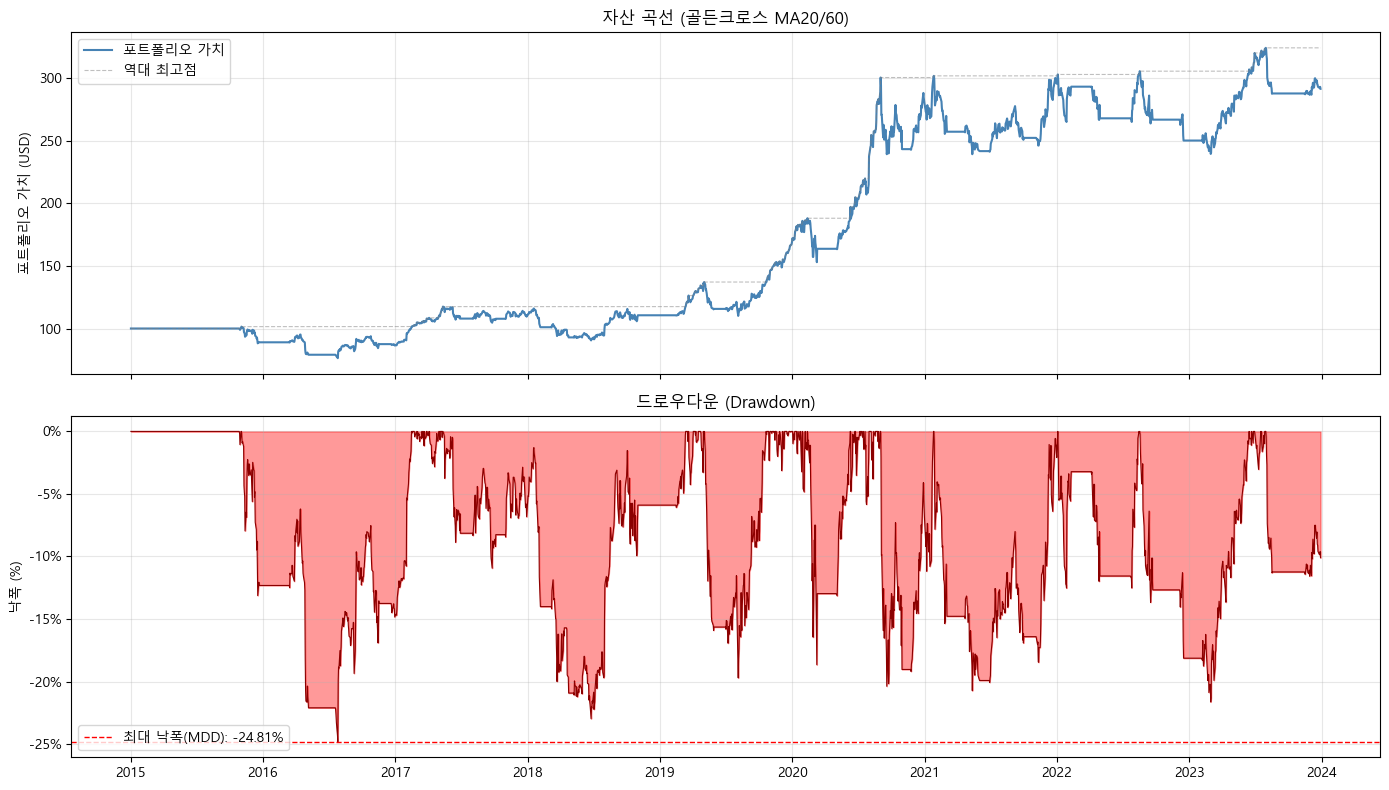

In [4]:
# 드로우다운(낙폭) 시각화 — matplotlib으로 직접 구현
equity = pf.value()
rolling_max = equity.cummax()
drawdown = (equity - rolling_max) / rolling_max

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 자산 곡선
ax1.plot(equity, color='steelblue', linewidth=1.5, label='포트폴리오 가치')
ax1.plot(rolling_max, color='gray', linewidth=0.8, linestyle='--', alpha=0.5, label='역대 최고점')
ax1.set_title('자산 곡선 (골든크로스 MA20/60)')
ax1.set_ylabel('포트폴리오 가치 (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 드로우다운 차트
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4)
ax2.plot(drawdown, color='darkred', linewidth=0.8)
ax2.axhline(mdd, color='red', linestyle='--', linewidth=1,
            label=f'최대 낙폭(MDD): {mdd:.2%}')
ax2.set_title('드로우다운 (Drawdown)')
ax2.set_ylabel('낙폭 (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

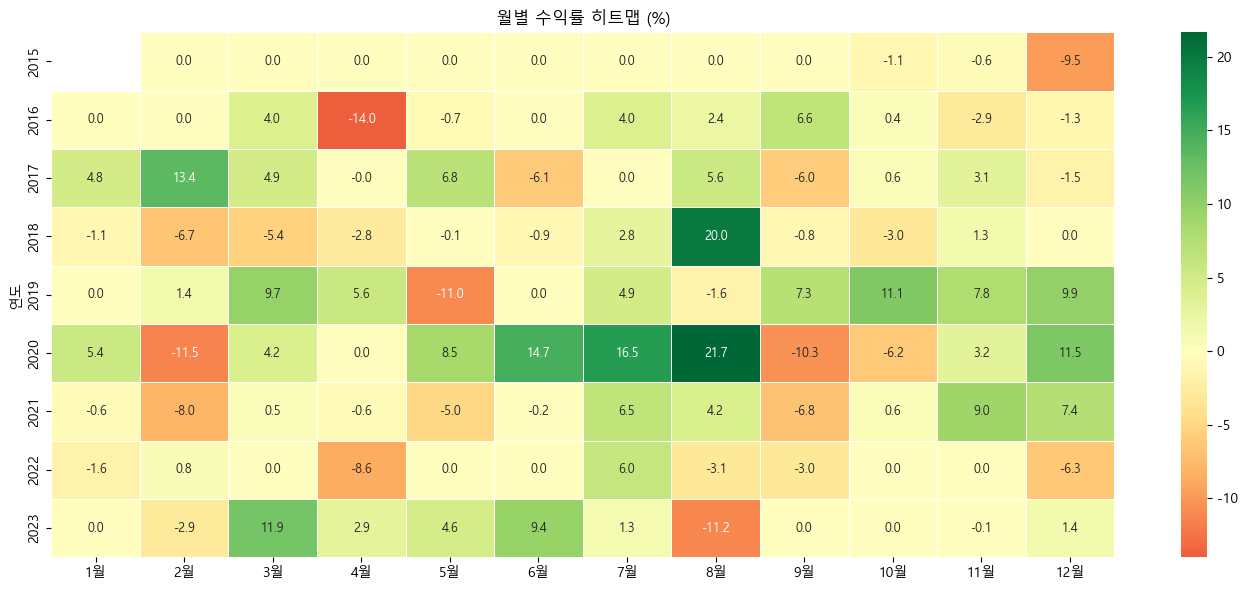

In [5]:
# 월별 수익률 히트맵 (직접 계산)
monthly_ret = pf.value().resample('M').last().pct_change()
monthly_ret.index = monthly_ret.index.to_period('M')

# 연도 x 월 피벗 테이블
pivot = pd.DataFrame({
    'year':  monthly_ret.index.year,
    'month': monthly_ret.index.month,
    'return': monthly_ret.values
})
pivot_table = pivot.pivot(index='year', columns='month', values='return')
pivot_table.columns = ['1월','2월','3월','4월','5월','6월',
                        '7월','8월','9월','10월','11월','12월'][:len(pivot_table.columns)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_table * 100,
    annot=True, fmt='.1f', cmap='RdYlGn',
    center=0, linewidths=0.5,
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title('월별 수익률 히트맵 (%)')
ax.set_ylabel('연도')
plt.tight_layout()
plt.show()

## 3. 파라미터 그리드 서치

최적의 파라미터 조합을 찾기 위해 여러 조합을 모두 테스트합니다.

### ⚠️ 중요 규칙
- 그리드 서치는 **in-sample 구간(학습 기간)** 에서만 수행
- 최적 파라미터를 **out-of-sample 구간(검증 기간)** 으로 반드시 검증

In [6]:
# ─── In-sample / Out-of-sample 분리 ──────────────────────────────
# 전체 기간 2015~2023 중:
#   In-sample  : 2015~2020 (학습)
#   Out-of-sample: 2021~2023 (검증)

split_date = '2021-01-01'

close_in  = close[close.index < split_date]    # 학습 기간
close_out = close[close.index >= split_date]   # 검증 기간

print(f'In-sample  (학습): {close_in.index[0].date()} ~ {close_in.index[-1].date()} ({len(close_in)}일)')
print(f'Out-of-sample(검증): {close_out.index[0].date()} ~ {close_out.index[-1].date()} ({len(close_out)}일)')

In-sample  (학습): 2015-01-02 ~ 2020-12-31 (1511일)
Out-of-sample(검증): 2021-01-04 ~ 2023-12-29 (753일)


In [ ]:
# ─── In-sample 그리드 서치 ────────────────────────────────────────
# optimizer.grid_search 가 fast/slow 조합을 자동으로 순회하며
# 샤프비율 기준 내림차순으로 정렬된 DataFrame 을 반환한다.
grid_df = grid_search(
    close_in,
    run_backtest,
    param_grid={
        "fast_window": [5, 10, 15, 20, 30],
        "slow_window": [40, 60, 90, 120],
    },
)

print(f'총 {len(grid_df)}개 파라미터 조합 테스트 완료')
print()
print('=== 샤프비율 상위 5개 조합 (In-sample) ===')
print(grid_df.head().to_string(index=False))

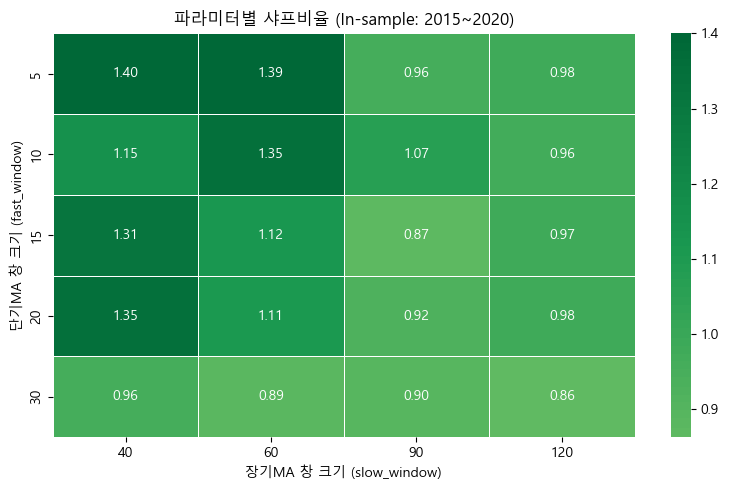

In [8]:
# ─── 샤프비율 히트맵 (In-sample) ─────────────────────────────────
# grid_search 결과 컬럼명: fast_window, slow_window
pivot_sharpe = grid_df.pivot(index='fast_window', columns='slow_window', values='sharpe_ratio')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_sharpe, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('파라미터별 샤프비율 (In-sample: 2015~2020)')
ax.set_xlabel('장기MA 창 크기 (slow_window)')
ax.set_ylabel('단기MA 창 크기 (fast_window)')
plt.tight_layout()
plt.show()

In [9]:
# ─── Out-of-sample 검증 ──────────────────────────────────────────
# In-sample에서 최적 파라미터 선택 (샤프비율 기준, grid_search 는 이미 내림차순 정렬)
best_row  = grid_df.iloc[0]
best_fast = int(best_row['fast_window'])
best_slow = int(best_row['slow_window'])

print(f'In-sample 최적 파라미터: fast={best_fast}, slow={best_slow}')
print(f'In-sample 샤프비율: {best_row["sharpe_ratio"]:.2f}')
print()

# 같은 파라미터로 Out-of-sample 검증
pf_oos = run_backtest(close_out, best_fast, best_slow)

print(f'=== Out-of-sample 검증 결과 (2021~2023) ===')
print(f'총 수익률 : {pf_oos.total_return():.2%}')
print(f'샤프비율  : {pf_oos.sharpe_ratio():.2f}')
print(f'최대낙폭  : {pf_oos.max_drawdown():.2%}')
print()

# Buy & Hold와 OOS 비교
bh_entries_oos = pd.Series(False, index=close_out.index)
bh_exits_oos   = pd.Series(False, index=close_out.index)
bh_entries_oos.iloc[0] = True
bh_exits_oos.iloc[-1]  = True
pf_bh_oos = vbt.Portfolio.from_signals(close_out, bh_entries_oos, bh_exits_oos,
                                        fees=0.001, freq='D')

print(f'=== Buy & Hold (같은 기간) ===')
print(f'총 수익률 : {pf_bh_oos.total_return():.2%}')
print(f'샤프비율  : {pf_bh_oos.sharpe_ratio():.2f}')

In-sample 최적 파라미터: fast=5, slow=40
In-sample 샤프비율: 1.40

=== Out-of-sample 검증 결과 (2021~2023) ===
총 수익률 : 30.16%
샤프비율  : 0.72
최대낙폭  : -25.25%

=== Buy & Hold (같은 기간) ===
총 수익률 : 51.10%
샤프비율  : 0.77


## 4. 과최적화(Overfitting) 시뮬레이션

In-sample에서만 최적화하고 OOS를 검증하지 않으면 어떤 결과가 나오는지 보여줍니다.

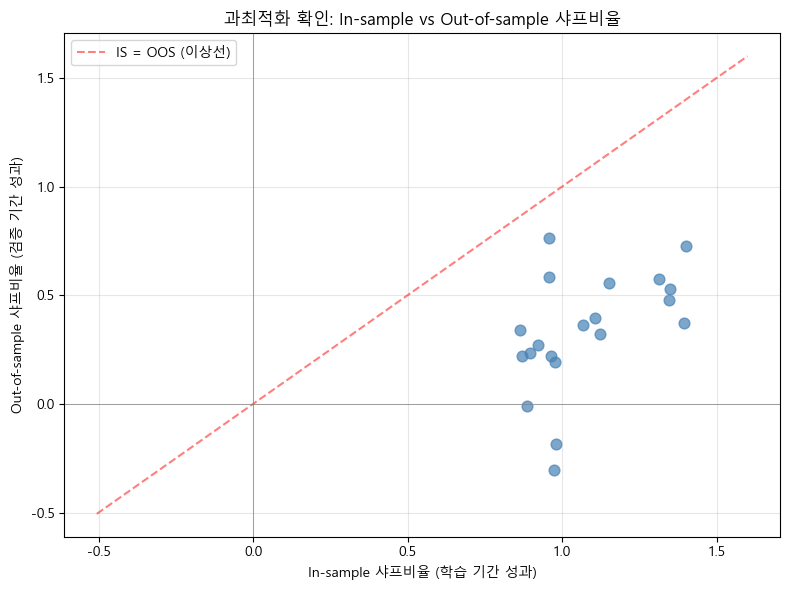


▶ 점들이 45도 선 아래에 몰려 있으면 과최적화 가능성이 높습니다.
▶ IS 샤프비율이 높아도 OOS에서 떨어지는 파라미터는 실전 사용 주의!


In [10]:
# 모든 파라미터의 In-sample vs Out-of-sample 성과 비교
oos_results = []

for _, row in grid_df.iterrows():
    fw, sw = int(row['fast_window']), int(row['slow_window'])
    try:
        pf_oos_temp = run_backtest(close_out, fw, sw)
        oos_results.append({
            'fast_window': fw, 'slow_window': sw,
            'in_sample_sharpe':  row['sharpe_ratio'],
            'out_sample_sharpe': pf_oos_temp.sharpe_ratio(),
        })
    except Exception:
        continue

oos_df = pd.DataFrame(oos_results)

# In-sample vs OOS 샤프비율 산점도
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(oos_df['in_sample_sharpe'], oos_df['out_sample_sharpe'],
           alpha=0.7, s=60, color='steelblue')

# 45도 기준선 (IS = OOS인 이상적인 경우)
lim_min = min(oos_df['in_sample_sharpe'].min(), oos_df['out_sample_sharpe'].min()) - 0.2
lim_max = max(oos_df['in_sample_sharpe'].max(), oos_df['out_sample_sharpe'].max()) + 0.2
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', alpha=0.5, label='IS = OOS (이상선)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

ax.set_xlabel('In-sample 샤프비율 (학습 기간 성과)')
ax.set_ylabel('Out-of-sample 샤프비율 (검증 기간 성과)')
ax.set_title('과최적화 확인: In-sample vs Out-of-sample 샤프비율')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n▶ 점들이 45도 선 아래에 몰려 있으면 과최적화 가능성이 높습니다.')
print('▶ IS 샤프비율이 높아도 OOS에서 떨어지는 파라미터는 실전 사용 주의!')

## 5. Walk-Forward 검증 (고급)

단순한 IS/OOS 분리보다 더 강건한 검증 방법입니다.  
시간을 이동하면서 반복적으로 학습·검증을 수행합니다.

```
기간: [====학습1====][검증1]
            [====학습2====][검증2]
                    [====학습3====][검증3]
```

In [ ]:
def walk_forward_test(
    close: pd.Series,
    train_years: int = 3,
    test_years: int = 1,
    fast_windows=None,
    slow_windows=None,
) -> pd.DataFrame:
    """
    Walk-Forward 검증
    - 매 step마다 train 구간으로 최적 파라미터 탐색
    - 최적 파라미터를 test 구간에 적용
    """
    if fast_windows is None:
        fast_windows = [10, 20, 30]
    if slow_windows is None:
        slow_windows = [60, 90, 120]

    start = close.index[0]
    end   = close.index[-1]
    wf_results = []

    train_start = start
    while True:
        train_end = train_start + pd.DateOffset(years=train_years)
        test_end  = train_end   + pd.DateOffset(years=test_years)

        if test_end > end:
            break

        c_train = close[(close.index >= train_start) & (close.index < train_end)]
        c_test  = close[(close.index >= train_end)   & (close.index < test_end)]

        if len(c_train) < 200 or len(c_test) < 50:
            break

        # In-sample 그리드 서치
        gs_result = grid_search(
            c_train,
            run_backtest,
            param_grid={"fast_window": fast_windows, "slow_window": slow_windows},
        )
        best_fw = int(gs_result.iloc[0]['fast_window'])
        best_sw = int(gs_result.iloc[0]['slow_window'])
        best_sharpe = gs_result.iloc[0]['sharpe_ratio']

        # Out-of-sample 적용
        try:
            pf_te = run_backtest(c_test, best_fw, best_sw)
            wf_results.append({
                'train_start': train_start.date(),
                'train_end':   train_end.date(),
                'test_start':  train_end.date(),
                'test_end':    test_end.date(),
                'best_fast':   best_fw,
                'best_slow':   best_sw,
                'IS_sharpe':   round(best_sharpe, 2),
                'OOS_return':  round(pf_te.total_return(), 4),
                'OOS_sharpe':  round(pf_te.sharpe_ratio(), 2),
            })
        except Exception:
            pass

        train_start += pd.DateOffset(years=test_years)

    return pd.DataFrame(wf_results)


wf_df = walk_forward_test(close, train_years=3, test_years=1)
print('=== Walk-Forward 검증 결과 ===')
print(wf_df.to_string(index=False))

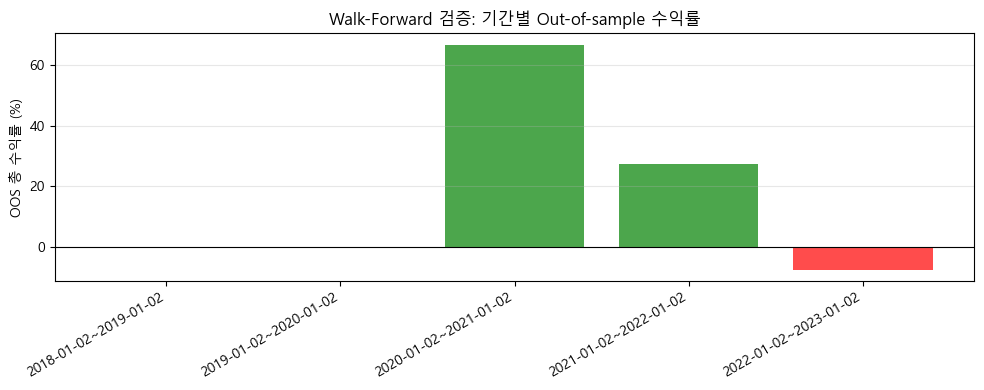

In [12]:
# Walk-Forward OOS 수익률 시각화
if len(wf_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['green' if r > 0 else 'red' for r in wf_df['OOS_return']]
    ax.bar(range(len(wf_df)), wf_df['OOS_return'] * 100, color=colors, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(wf_df)))
    ax.set_xticklabels(
        [f"{r['test_start']}~{r['test_end']}" for _, r in wf_df.iterrows()],
        rotation=30, ha='right'
    )
    ax.set_ylabel('OOS 총 수익률 (%)')
    ax.set_title('Walk-Forward 검증: 기간별 Out-of-sample 수익률')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 이번 단계 정리

| 개념 | 핵심 내용 |
|-----|----------|
| **pf.stats()** | 샤프비율·MDD·승률 등 모든 지표 한 번에 확인 |
| **드로우다운** | 고점 대비 하락폭 — 낮을수록 리스크 작음 |
| **그리드 서치** | 모든 파라미터 조합 테스트 → 최적값 탐색 |
| **과최적화** | IS에서 좋은 파라미터 ≠ OOS에서 좋은 파라미터 |
| **Walk-Forward** | 시간이동하며 IS/OOS 반복 검증 → 가장 신뢰할 수 있는 방법 |

### ⚠️ 황금 규칙
1. 파라미터 최적화는 **In-sample에서만**
2. 최종 평가는 **Out-of-sample에서만**
3. OOS 결과가 IS보다 크게 낮으면 **전략을 버려야 함**

### 다음 단계
5단계에서는 **멀티 자산 백테스팅**, **포트폴리오 비중 최적화**, **나만의 전략 라이브러리 구축**을 배웁니다.